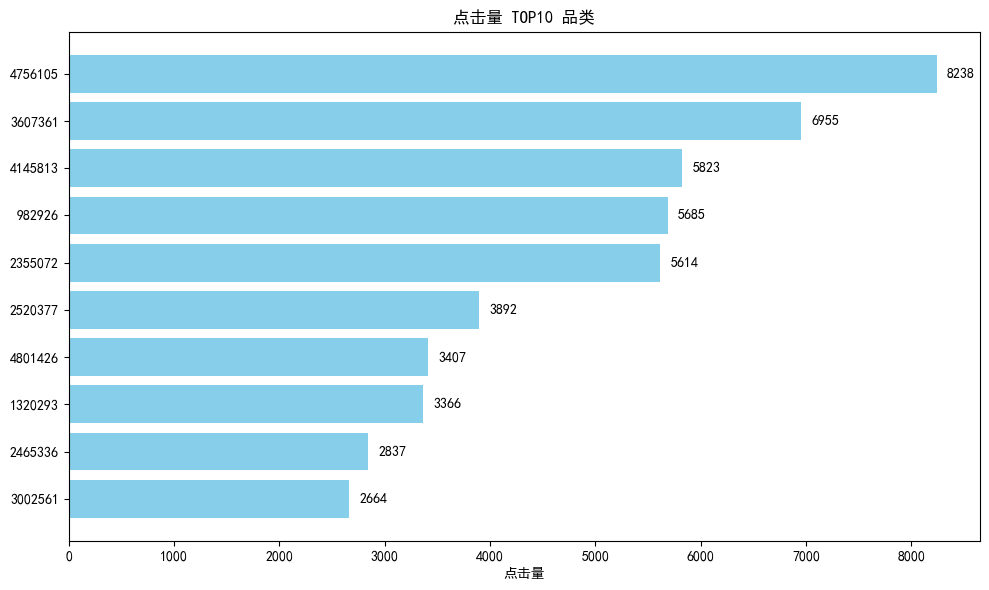

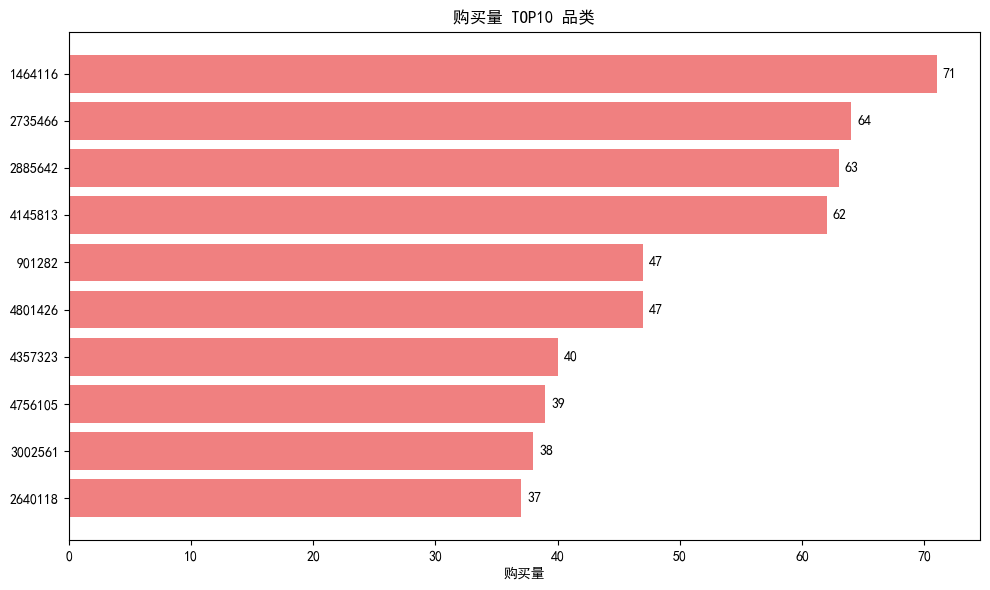

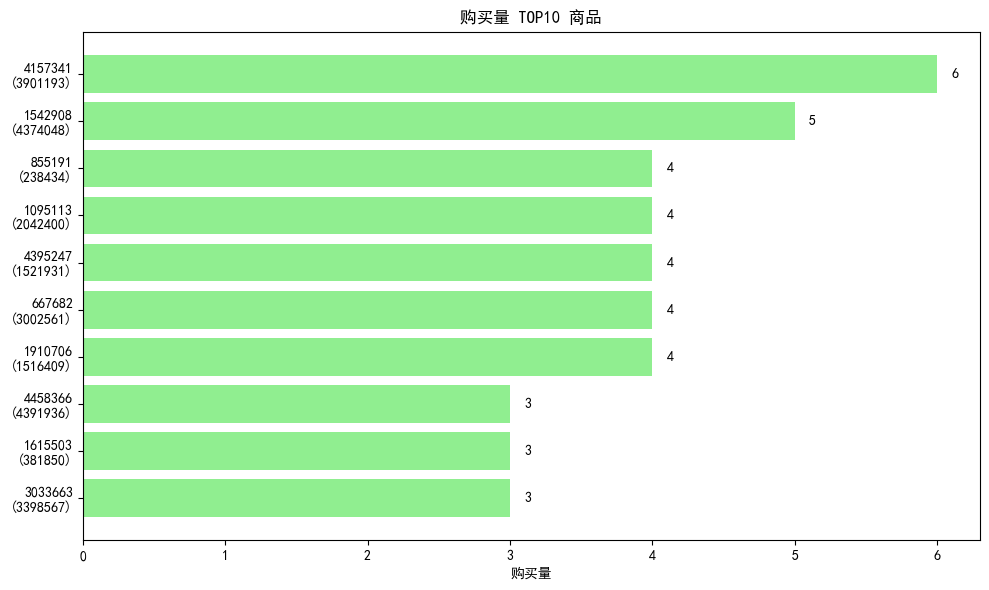

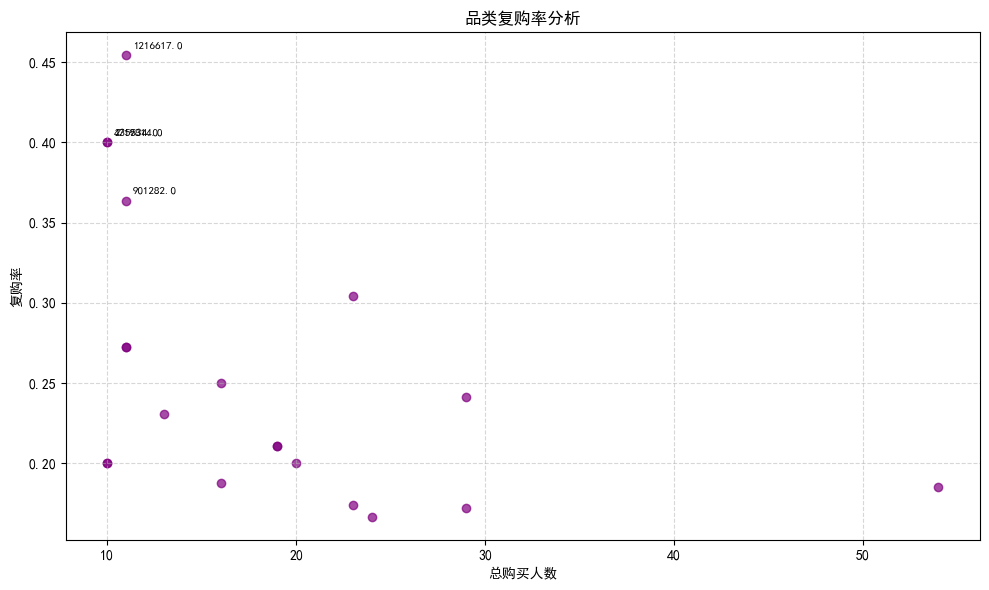

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df_pv = pd.read_csv('E:/ecommerce-analysis/data/top_categories_by_pv.csv')
df_buy = pd.read_csv('E:/ecommerce-analysis/data/top_categories_by_buy.csv')
df_items = pd.read_csv('E:/ecommerce-analysis/data/top_items.csv')
df_repeat = pd.read_csv('E:/ecommerce-analysis/data/category_repeat_rate.csv')

# 1. 点击量 TOP10 品类（数值较大，用万或千为单位）
plt.figure(figsize=(10,6))
bars = plt.barh(df_pv['category_id'].astype(str), df_pv['pv'], color='skyblue')
plt.xlabel('点击量')
plt.title('点击量 TOP10 品类')
plt.gca().invert_yaxis()
# 在条形末尾添加数值标签
for bar, val in zip(bars, df_pv['pv']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, f'{val}', va='center')
plt.tight_layout()
plt.savefig('E:/ecommerce-analysis/images/top_categories_pv.png')
plt.show()

# 2. 购买量 TOP10 品类（数值较小，37~71）
plt.figure(figsize=(10,6))
bars = plt.barh(df_buy['category_id'].astype(str), df_buy['buy_cnt'], color='lightcoral')
plt.xlabel('购买量')
plt.title('购买量 TOP10 品类')
plt.gca().invert_yaxis()
for bar, val in zip(bars, df_buy['buy_cnt']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val}', va='center')
plt.tight_layout()
plt.savefig('E:/ecommerce-analysis/images/top_categories_buy.png')
plt.show()

# 3. 商品级别购买量 TOP10（数值 3~6，较小）
plt.figure(figsize=(10,6))
# 构造商品标签：item_id (category_id)
labels = [f"{row['item_id']}\n({row['category_id']})" for _, row in df_items.iterrows()]
bars = plt.barh(labels, df_items['buy_cnt'], color='lightgreen')
plt.xlabel('购买量')
plt.title('购买量 TOP10 商品')
plt.gca().invert_yaxis()
for bar, val in zip(bars, df_items['buy_cnt']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val}', va='center')
plt.tight_layout()
plt.savefig('E:/ecommerce-analysis/images/top_items.png')
plt.show()

# 4. 品类复购率散点图（total_buyers 范围 10~54，repeat_rate 0.16~0.45）
plt.figure(figsize=(10,6))
plt.scatter(df_repeat['total_buyers'], df_repeat['repeat_rate'], alpha=0.7, color='purple')
plt.xlabel('总购买人数')
plt.ylabel('复购率')
plt.title('品类复购率分析')
plt.grid(True, linestyle='--', alpha=0.5)
# 标注复购率较高的品类
high_rep = df_repeat[df_repeat['repeat_rate'] > 0.35]
for _, row in high_rep.iterrows():
    plt.annotate(row['category_id'], (row['total_buyers'], row['repeat_rate']),
                 xytext=(5,5), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.savefig('E:/ecommerce-analysis/images/category_repeat_rate.png')
plt.show()